# NAV Trend Analysis 2022–2026
## Daily NAV for all 40 schemes with 2023 bull run & 2024 corrections highlighted
# NAV (Net Asset Value) Formula:



EDA of The Processed data 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime


GET THAT PROCESSED CLEANED DATA

In [2]:
fm = pd.read_csv("data/processed/01_fund_master.csv",parse_dates=["launch_date"])
nav = pd.read_csv("data/processed/02_nav_history.csv",parse_dates=["date"])
print("Fund Master Shape:", fm.shape)
print("NAV History Shape:", nav.shape)


Fund Master Shape: (40, 15)
NAV History Shape: (64320, 5)


In [3]:
# fm.shape
# fm.describe(include="all")   
### ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
###        Total Assets - Total Liabilities
### NAV = ──────────────────────────────────                FOR a Mutual FUND 
###        Total Outstanding Units
### ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



Task 1 : NAV trend analysis — plot daily NAV for all 40 schemes 2022–2026. Highlight 2023 bull run and 2024 market corrections using Plotly.
x = Date
y = NAV
color = Scheme

In [4]:
nav_df=nav.merge(fm[[
    "amfi_code","scheme_name","fund_house","category","sub_category"
    ]]
    ,on="amfi_code",how="left") #Left Outer Join

In [5]:
nav_df.isnull().sum()   # Check for missing values espacially for Schema

amfi_code            0
date                 0
date_key             0
nav                  0
is_forward_filled    0
scheme_name          0
fund_house           0
category             0
sub_category         0
dtype: int64

In [6]:
nav_df.head()

,amfi_code,date,date_key,nav,is_forward_filled,scheme_name,fund_house,category,sub_category
0,100016,2022-01-03,20220103,520.4608,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap
1,100016,2022-01-04,20220104,515.0971,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap
2,100016,2022-01-05,20220105,521.7239,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap
3,100016,2022-01-06,20220106,515.7880,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap
4,100016,2022-01-07,20220107,515.1639,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap


In [7]:
nav_df = nav_df[
    (nav_df["date"] >= "2022-01-01")
    &
    (nav_df["date"] <= "2025-12-31")
]

In [8]:
nav_df["date"].max()
nav_df["scheme_name"].nunique()

40

## Normalized NAV Index

Indexed NAV (Normalized NAV) converts different funds' NAVs to a common starting value so you can compare relative performance over time.

**Formula (LaTeX):**

$$
\mathrm{Indexed\ NAV}_t = \frac{\mathrm{NAV}_t}{\mathrm{NAV}_{\text{start}}} \times 100
$$

### Why normalize?

A fund with NAV 500 and a fund with NAV 20 cannot be visually compared directly.

Indexing all funds to 100 at the start date allows direct performance comparison.

This method highlights relative returns (percentage growth) and is standard practice for comparing funds.

### Chart A    Date vs NAV   40 schemes
### Chart B     All funds start at 100        Performance comparison
# NAV Trend Analysis (2022–2025)

Objective:
Analyze historical NAV movements across all 40 mutual fund schemes.
The analysis highlights:
- 2023 market bull run
- 2024 market correction phase
- Relative fund performance using indexed NAV


In [9]:
print(fm.shape)
print(nav.shape)
print(nav_df["scheme_name"].nunique())
print(nav_df["date"].min())
print(nav_df["date"].max())

(40, 15)
(64320, 5)
40
2022-01-03 00:00:00
2025-12-31 00:00:00


In [10]:
# sort
nav_df=nav_df.sort_values(["scheme_name","date"])

#First NAV of each scheme
# so basically we are grouping the data by "scheme_name" and then applying the "transform" function to the "nav" column to get the first value of "nav" for each group (scheme). This will create a new column "first_nav" in the DataFrame where each row will have the first NAV value corresponding to its scheme.
first_nav=nav_df.groupby(
    "scheme_name"
    )["nav"].transform("first")  

#INDEX NAV = (Current NAV / First NAV) * 100

nav_df["indexed_nav"]=(
    nav_df["nav"]/first_nav
)*100


In [11]:
import plotly.express as px
fig=px.line(
    nav_df,
    x="date",
    y="indexed_nav",
    color="scheme_name",
    title="Indexed NAV of MFS over (2022-2025)",
    labels={
        "indexed_nav":"INDEXED NAV(Based =100)",
        "date":"Date",
        "scheme_name":"Scheme"
    }
)

#Jan 2023 → Dec 2023 - Bull Run for MFs
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)
#Jan 2024 → Dec 2024 - Bear Run for MFs
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-04-30",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    height=800,
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="v"
    )
)


fig.show()


In [12]:
nav_df["category"].value_counts()

category
Equity    49606
Debt       8754
Name: count, dtype: int64

In [13]:
nav_df["fund_house"].value_counts()

fund_house
ICICI Prudential MF         7295
HDFC Mutual Fund            7295
SBI Mutual Fund             7295
Nippon India MF             7295
Kotak Mahindra MF           5836
Axis Mutual Fund            5836
Aditya Birla Sun Life MF    4377
DSP Mutual Fund             4377
Mirae Asset MF              4377
UTI Mutual Fund             4377
Name: count, dtype: int64

In [14]:
from plotly import express as px
from pathlib import Path

results_dir = Path(r"d:\BlueStocks\MFA\Results")
results_dir.mkdir(exist_ok=True)

def save_plotly_figure(fig, file_name):
    file_path = results_dir / file_name
    fig.write_image(str(file_path), format="png", width=1600, height=900, scale=2)
    print(f"Saved {file_path.name}")

amc_trend = (
    nav_df
    .groupby(["date", "fund_house"])["indexed_nav"]
    .mean()
    .reset_index()
)

title = "Average Indexed NAV by Fund House (2022-2025)"
fig = px.line(
    amc_trend,
    x="date",
    y="indexed_nav",
    color="fund_house",
    title=title,
    labels={
        "indexed_nav": "Indexed NAV (Base=100)",
        "fund_house": "Fund House"
    }
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    line_width=0,
    annotation_text="2023 Bull Run"
)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-04-30",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Correction"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    hovermode="x unified",
    legend_title="Fund House"
)

save_plotly_figure(fig, "Average Indexed NAV by Fund House (2022-2025).png")
fig.show()


Saved Average Indexed NAV by Fund House (2022-2025).png


In [15]:
from plotly import express as px
from pathlib import Path

results_dir = Path(r"d:\BlueStocks\MFA\Results")
results_dir.mkdir(exist_ok=True)

def save_plotly_figure(fig, file_name):
    file_path = results_dir / file_name
    fig.write_image(str(file_path), format="png", width=1600, height=900, scale=2)
    print(f"Saved {file_path.name}")

nav_df.groupby("sub_category")["scheme_name"].nunique()
category_trend = (
    nav_df
    .groupby(["date", "sub_category"])["indexed_nav"]
    .mean()
    .reset_index()
)
title = "Average Indexed NAV by Fund Category (2022-2025)"
fig = px.line(
    category_trend,
    x="date",
    y="indexed_nav",
    color="sub_category",
    title=title
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.1,
    line_width=0,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-04-30",
    fillcolor="red",
    opacity=0.1,
    line_width=0,
    annotation_text="2024 Correction"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700
)

save_plotly_figure(fig, "Average Indexed NAV by Fund Category (2022-2025).png")
fig.show()



Saved Average Indexed NAV by Fund Category (2022-2025).png


In [16]:
from plotly import express as px
from pathlib import Path

results_dir = Path(r"d:\BlueStocks\MFA\Results")
results_dir.mkdir(exist_ok=True)

def save_plotly_figure(fig, file_name):
    file_path = results_dir / file_name
    fig.write_image(str(file_path), format="png", width=1600, height=900, scale=2)
    print(f"Saved {file_path.name}")

scheme_growth = (
    nav_df
    .groupby("scheme_name")
    .agg(
        start_nav=("indexed_nav", "first"),
        end_nav=("indexed_nav", "last")
    )
)

scheme_growth["growth_pct"] = (
    scheme_growth["end_nav"] - 100
)
top10 = (
    scheme_growth
    .sort_values(
        "growth_pct",
        ascending=False
    )
    .head(10)
    .index
)
top10_df = nav_df[
    nav_df["scheme_name"].isin(top10)
]

title = "Top 10 Performing Mutual Fund Schemes"
fig = px.line(
    top10_df,
    x="date",
    y="indexed_nav",
    color="scheme_name",
    title=title
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700
)

save_plotly_figure(fig, "Top 10 Performing Mutual Fund Schemes.png")
fig.show()


Saved Top 10 Performing Mutual Fund Schemes.png


In [17]:
aum=pd.read_csv("data/processed/03_aum_by_fund_house.csv",parse_dates=["date"])
print(aum.shape)

aum.head()

aum.info()

(90, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
 5   date_key        90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 4.3+ KB


In [18]:
print(aum["fund_house"].nunique())

print(aum["date"].min())

print(aum["date"].max())

10
2022-03-31 00:00:00
2025-12-31 00:00:00


In [19]:
aum["date"].dt.year.value_counts().sort_index()

date
2022    20
2023    20
2024    30
2025    20
Name: count, dtype: int64

In [20]:
aum.shape
aum.head()
aum.info()
aum["date"].dt.year.value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
 5   date_key        90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 4.3+ KB


date
2022    20
2023    20
2024    30
2025    20
Name: count, dtype: int64

In [21]:
aum.sort_values("date").tail(20)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,date_key
79,2025-03-31,UTI Mutual Fund,3.55,355000,142,20250331
78,2025-03-31,SBI Mutual Fund,12.50,1250000,186,20250331
76,2025-03-31,Mirae Asset MF,2.25,225000,56,20250331
75,2025-03-31,Kotak Mahindra MF,4.92,492000,168,20250331
77,2025-03-31,Nippon India MF,5.60,560000,177,20250331
73,2025-03-31,HDFC Mutual Fund,7.95,795000,195,20250331
72,2025-03-31,DSP Mutual Fund,1.95,195000,88,20250331
71,2025-03-31,Axis Mutual Fund,3.10,310000,95,20250331
70,2025-03-31,Aditya Birla Sun Life MF,3.85,385000,199,20250331
74,2025-03-31,ICICI Prudential MF,8.80,880000,216,20250331


In [22]:
aum.sort_values("date").head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,date_key
0,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199,20220331
1,2022-03-31,Axis Mutual Fund,2.50,250000,95,20220331
2,2022-03-31,DSP Mutual Fund,1.10,110000,88,20220331
3,2022-03-31,HDFC Mutual Fund,4.35,435000,195,20220331
4,2022-03-31,ICICI Prudential MF,4.65,465000,216,20220331
5,2022-03-31,Kotak Mahindra MF,2.70,270000,168,20220331
6,2022-03-31,Mirae Asset MF,1.05,105000,56,20220331
7,2022-03-31,Nippon India MF,2.70,270000,177,20220331
8,2022-03-31,SBI Mutual Fund,6.05,605000,186,20220331
9,2022-03-31,UTI Mutual Fund,2.30,230000,142,20220331


In [23]:
aum["date"].drop_duplicates().sort_values().tolist()



[Timestamp('2022-03-31 00:00:00'),
 Timestamp('2022-09-30 00:00:00'),
 Timestamp('2023-03-31 00:00:00'),
 Timestamp('2023-09-30 00:00:00'),
 Timestamp('2024-03-31 00:00:00'),
 Timestamp('2024-09-30 00:00:00'),
 Timestamp('2024-12-31 00:00:00'),
 Timestamp('2025-03-31 00:00:00'),
 Timestamp('2025-12-31 00:00:00')]

## AUM Growth Analysis

Assets Under Management (AUM) trends were analyzed across
10 leading fund houses from 2022–2025.

For each year, the latest available snapshot was selected
to enable consistent year-over-year comparison.

In [24]:
# Create year column

aum["year"] = aum["date"].dt.year

# Keep latest available record in each year

aum_yearly = (
    aum
    .sort_values("date")
    .groupby(
        ["year", "fund_house"],
        as_index=False
    )
    .last()
)

aum_yearly.head()

,year,fund_house,date,aum_lakh_crore,aum_crore,num_schemes,date_key
0,2022,Aditya Birla Sun Life MF,2022-09-30,2.85,285000,199,20220930
1,2022,Axis Mutual Fund,2022-09-30,2.40,240000,95,20220930
2,2022,DSP Mutual Fund,2022-09-30,1.12,112000,88,20220930
3,2022,HDFC Mutual Fund,2022-09-30,4.45,445000,195,20220930
4,2022,ICICI Prudential MF,2022-09-30,4.88,488000,216,20220930


In [25]:
print(aum_yearly.shape)

aum_yearly.groupby("year").size()

(40, 7)


year
2022    10
2023    10
2024    10
2025    10
dtype: int64

In [26]:
aum_yearly.pivot(
    index="fund_house",
    columns="year",
    values="aum_lakh_crore"
).round(2)

year,2022,2023,2024,2025
fund_house,,,,
Aditya Birla Sun Life MF,2.85,3.08,3.84,4.60
Axis Mutual Fund,2.40,2.60,3.00,3.50
DSP Mutual Fund,1.12,1.32,1.88,2.30
HDFC Mutual Fund,4.45,5.35,7.87,9.30
ICICI Prudential MF,4.88,5.90,8.74,10.74
Kotak Mahindra MF,2.72,3.25,4.89,5.80
Mirae Asset MF,1.08,1.42,2.10,2.90
Nippon India MF,2.78,3.40,5.70,7.00
SBI Mutual Fund,6.30,8.45,11.14,12.50


SBI Mutual Fund emerged as the industry leader, reaching
₹12.5 lakh crore AUM by 2025.

Saved aum_growth_by_fund_house_2022_2025_2.png


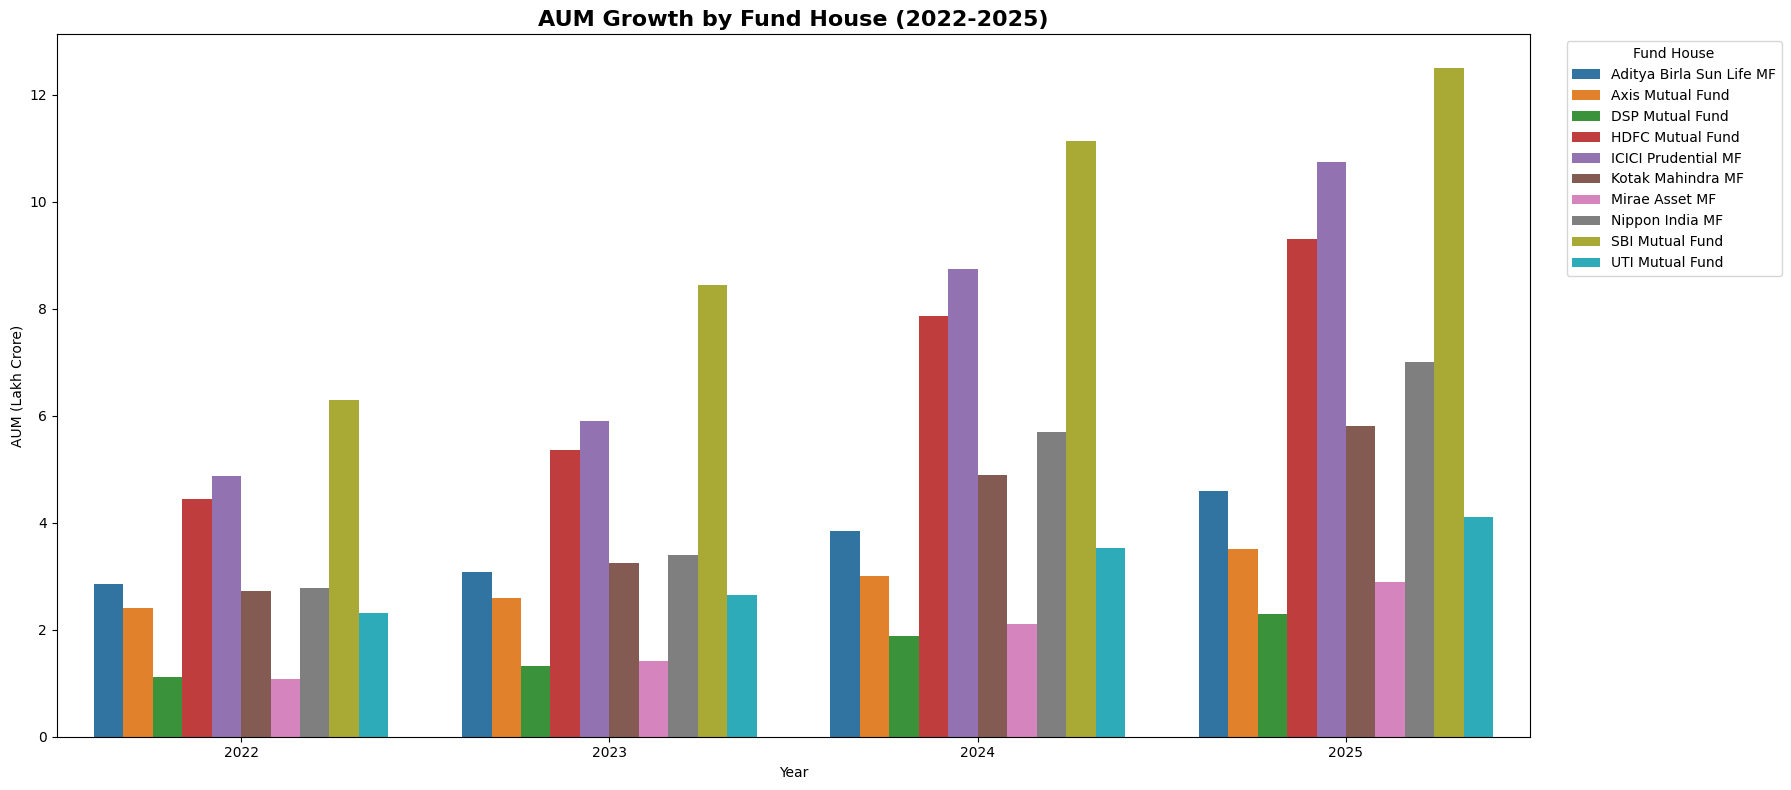

In [27]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import seaborn as sns

results_dir = Path("Results")
results_dir.mkdir(exist_ok=True)


def _safe_filename(text, fallback):
    text = re.sub(r"[^\w\s-]", "", text).strip().lower()
    text = re.sub(r"[-\s]+", "_", text)
    return text or fallback


def save_current_figure(name):
    base = _safe_filename(name, "figure")
    file_path = results_dir / f"{base}.png"
    suffix = 2
    while file_path.exists():
        file_path = results_dir / f"{base}_{suffix}.png"
        suffix += 1
    plt.gcf().savefig(file_path, bbox_inches="tight", dpi=300)
    print(f"Saved {file_path.name}")


plt.figure(figsize=(18,8))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
save_current_figure("AUM Growth by Fund House (2022-2025)")
plt.show()


In [28]:
nav_df["category"].value_counts()

category
Equity    49606
Debt       8754
Name: count, dtype: int64

In [29]:
nav_df[
    ["scheme_name","fund_house","category"]
].drop_duplicates().sort_values(
    ["category","fund_house"]
)

,scheme_name,fund_house,category
8040,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt
1608,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt
43416,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt
49848,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt
20904,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Debt
28944,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt
4824,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
6432,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
24120,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity
22512,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity


In [30]:
selected_funds = [
    "HDFC Top 100 Fund - Regular Plan - Growth",
    "ICICI Pru Bluechip Fund - Regular - Growth",
    "Axis Midcap Fund - Regular - Growth",
    "UTI Mid Cap Fund - Regular - Growth",
    "SBI Small Cap Fund - Regular Plan - Growth",
    "Nippon India Small Cap Fund - Regular - Growth",
    "UTI Flexi Cap Fund - Regular - Growth",
    "ICICI Pru Value Discovery Fund - Regular - Growth",
    "Kotak Flexicap Fund - Regular - Growth",
    "Mirae Asset Emerging Bluechip Fund - Regular - Growth"
]

In [31]:
selected_funds = [
    "HDFC Top 100 Fund - Regular Plan - Growth",
    "ICICI Pru Bluechip Fund - Regular - Growth",
    "Axis Midcap Fund - Regular - Growth",
    "UTI Mid Cap Fund - Regular - Growth",
    "SBI Small Cap Fund - Regular Plan - Growth",
    "Nippon India Small Cap Fund - Regular - Growth",
    "UTI Flexi Cap Fund - Regular - Growth",
    "ICICI Pru Value Discovery Fund - Regular - Growth",
    "Kotak Flexicap Fund - Regular - Growth",
    "Mirae Asset Emerging Bluechip Fund - Regular - Growth"
]

corr_df = nav_df[
    nav_df["scheme_name"].isin(selected_funds)
].copy()

nav_pivot = corr_df.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

print(nav_pivot.shape)

(1459, 10)


In [32]:
returns = nav_pivot.pct_change()
returns = returns.dropna()
corr_matrix = returns.corr()

corr_matrix.round(2)

scheme_name,Axis Midcap Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Pru Value Discovery Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Emerging Bluechip Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,SBI Small Cap Fund - Regular Plan - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth
scheme_name,,,,,,,,,,
Axis Midcap Fund - Regular - Growth,1.00,-0.05,0.06,0.01,0.05,0.03,-0.03,0.05,-0.02,-0.03
HDFC Top 100 Fund - Regular Plan - Growth,-0.05,1.00,0.03,0.02,0.02,-0.00,0.03,-0.05,-0.01,-0.00
ICICI Pru Bluechip Fund - Regular - Growth,0.06,0.03,1.00,-0.00,0.01,0.03,-0.00,-0.02,-0.06,0.04
ICICI Pru Value Discovery Fund - Regular - Growth,0.01,0.02,-0.00,1.00,0.07,-0.05,-0.03,0.01,0.01,-0.01
Kotak Flexicap Fund - Regular - Growth,0.05,0.02,0.01,0.07,1.00,0.01,0.05,-0.06,0.02,-0.04
Mirae Asset Emerging Bluechip Fund - Regular - Growth,0.03,-0.00,0.03,-0.05,0.01,1.00,0.04,0.01,-0.05,0.02
Nippon India Small Cap Fund - Regular - Growth,-0.03,0.03,-0.00,-0.03,0.05,0.04,1.00,-0.01,-0.02,-0.02
SBI Small Cap Fund - Regular Plan - Growth,0.05,-0.05,-0.02,0.01,-0.06,0.01,-0.01,1.00,-0.02,0.01
UTI Flexi Cap Fund - Regular - Growth,-0.02,-0.01,-0.06,0.01,0.02,-0.05,-0.02,-0.02,1.00,0.01


Saved correlation_matrix_of_daily_fund_returns_2.png


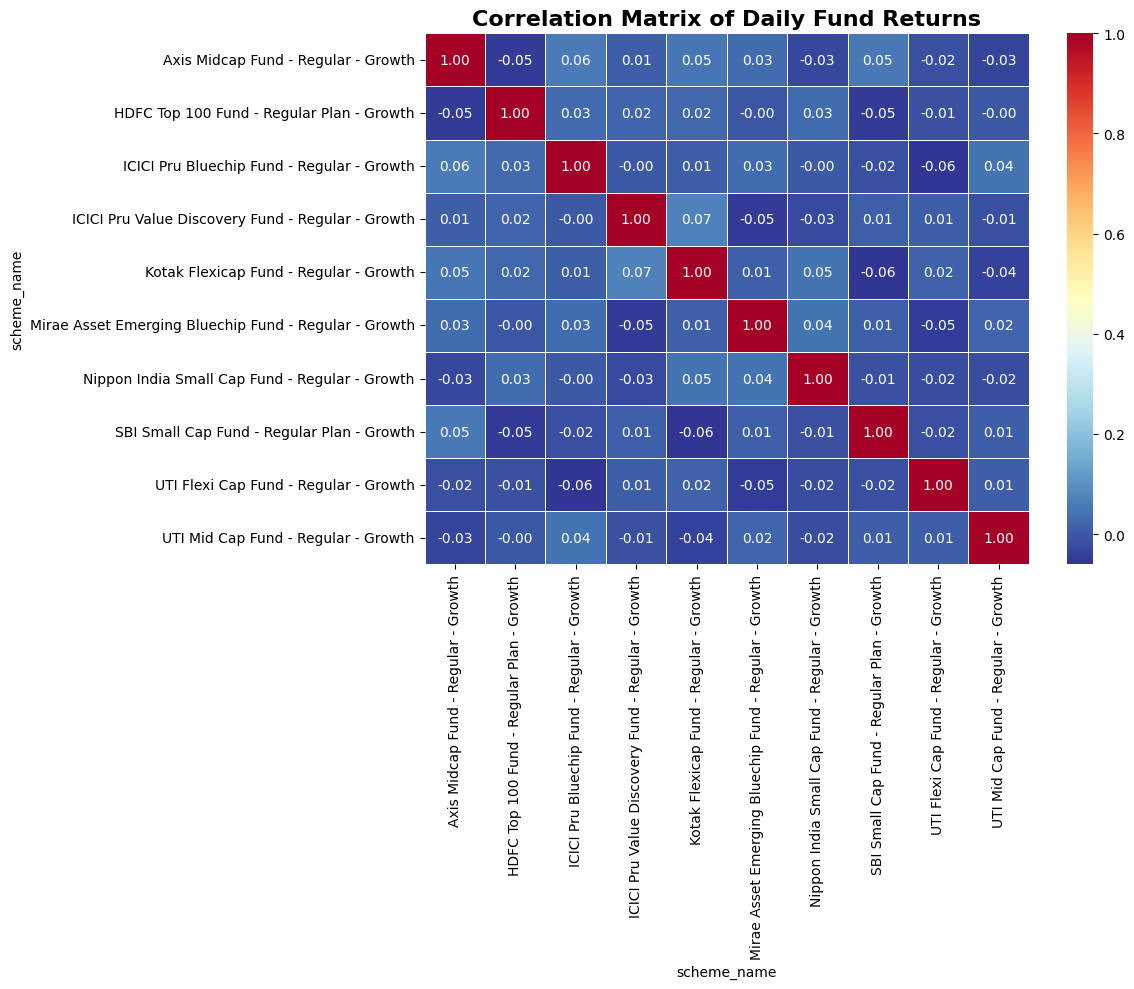

In [33]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import seaborn as sns

results_dir = Path("Results")
results_dir.mkdir(exist_ok=True)


def _safe_filename(text, fallback):
    text = re.sub(r"[^\w\s-]", "", text).strip().lower()
    text = re.sub(r"[-\s]+", "_", text)
    return text or fallback


def save_current_figure(name):
    base = _safe_filename(name, "figure")
    file_path = results_dir / f"{base}.png"
    suffix = 2
    while file_path.exists():
        file_path = results_dir / f"{base}_{suffix}.png"
        suffix += 1
    plt.gcf().savefig(file_path, bbox_inches="tight", dpi=300)
    print(f"Saved {file_path.name}")


plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily Fund Returns",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
save_current_figure("Correlation Matrix of Daily Fund Returns")

plt.show()


In [34]:
corr_matrix.round(2)

scheme_name,Axis Midcap Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Pru Value Discovery Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Emerging Bluechip Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,SBI Small Cap Fund - Regular Plan - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth
scheme_name,,,,,,,,,,
Axis Midcap Fund - Regular - Growth,1.00,-0.05,0.06,0.01,0.05,0.03,-0.03,0.05,-0.02,-0.03
HDFC Top 100 Fund - Regular Plan - Growth,-0.05,1.00,0.03,0.02,0.02,-0.00,0.03,-0.05,-0.01,-0.00
ICICI Pru Bluechip Fund - Regular - Growth,0.06,0.03,1.00,-0.00,0.01,0.03,-0.00,-0.02,-0.06,0.04
ICICI Pru Value Discovery Fund - Regular - Growth,0.01,0.02,-0.00,1.00,0.07,-0.05,-0.03,0.01,0.01,-0.01
Kotak Flexicap Fund - Regular - Growth,0.05,0.02,0.01,0.07,1.00,0.01,0.05,-0.06,0.02,-0.04
Mirae Asset Emerging Bluechip Fund - Regular - Growth,0.03,-0.00,0.03,-0.05,0.01,1.00,0.04,0.01,-0.05,0.02
Nippon India Small Cap Fund - Regular - Growth,-0.03,0.03,-0.00,-0.03,0.05,0.04,1.00,-0.01,-0.02,-0.02
SBI Small Cap Fund - Regular Plan - Growth,0.05,-0.05,-0.02,0.01,-0.06,0.01,-0.01,1.00,-0.02,0.01
UTI Flexi Cap Fund - Regular - Growth,-0.02,-0.01,-0.06,0.01,0.02,-0.05,-0.02,-0.02,1.00,0.01


In [35]:
returns = nav_pivot.pct_change().dropna()

returns.describe().T[
    ["mean","std","min","max"]
]


,mean,std,min,max
scheme_name,,,,
Axis Midcap Fund - Regular - Growth,0.000753,0.010304,-0.040755,0.041591
HDFC Top 100 Fund - Regular Plan - Growth,0.000156,0.007681,-0.024744,0.028232
ICICI Pru Bluechip Fund - Regular - Growth,0.000506,0.007409,-0.025900,0.026845
ICICI Pru Value Discovery Fund - Regular - Growth,0.000428,0.008160,-0.033230,0.043812
Kotak Flexicap Fund - Regular - Growth,0.000847,0.008557,-0.029748,0.033554
Mirae Asset Emerging Bluechip Fund - Regular - Growth,0.000588,0.008300,-0.026127,0.031415
Nippon India Small Cap Fund - Regular - Growth,0.000391,0.013506,-0.058102,0.059304
SBI Small Cap Fund - Regular Plan - Growth,0.000804,0.013352,-0.045180,0.064713
UTI Flexi Cap Fund - Regular - Growth,0.000520,0.008450,-0.031271,0.031256


In [36]:
nav_pivot.head()

scheme_name,Axis Midcap Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Pru Value Discovery Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Emerging Bluechip Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,SBI Small Cap Fund - Regular Plan - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,68.3023,520.4608,55.3983,202.0453,49.9131,84.0757,69.1076,89.8738,191.0721,119.2905
2022-01-04,68.0566,515.0971,55.6327,202.1501,50.8195,85.4096,68.8538,88.5495,189.0737,120.6402
2022-01-05,69.1860,521.7239,55.9527,203.6057,50.1942,84.7554,69.0511,88.0925,188.0701,121.4580
2022-01-06,69.1690,515.7880,56.6067,202.2714,50.6213,84.3563,68.4476,88.5175,190.4545,125.2386
2022-01-07,67.8877,515.1639,57.5741,203.3482,49.9391,84.9469,67.0371,91.4235,187.3124,124.1321


## Sector Allocation Analysis

Portfolio holdings across equity mutual funds were aggregated to evaluate sector exposure.

Sector-level weights reveal where fund managers collectively allocate capital and highlight the dominant themes within Indian equity portfolios.

In [37]:
holdings = pd.read_csv(
    "data/processed/09_portfolio_holdings.csv"
)

print(holdings.shape)

holdings.head()

holdings.info()
print(holdings.shape)

holdings.columns.tolist()

holdings.head()

(322, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
 8   date_key           322 non-null    int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 22.8+ KB
(322, 9)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,date_key
0,100016,BAJFINANCE,Bajaj Finance Ltd,NBFC,7.01,214.89,592.41,2025-12-31,20251231
1,100016,CIPLA,Cipla Ltd,Pharma,4.92,1325.34,4188.12,2025-12-31,20251231
2,100016,DRREDDY,Dr. Reddy's Laboratories,Pharma,9.03,452.67,2212.60,2025-12-31,20251231
3,100016,HINDUNILVR,Hindustan Unilever Ltd,FMCG,11.68,1590.03,2555.06,2025-12-31,20251231
4,100016,ICICIBANK,ICICI Bank Ltd,Banking,3.39,169.92,4888.66,2025-12-31,20251231


In [38]:
holdings["amfi_code"].nunique()


34

In [39]:
holdings["sector"].value_counts()


sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

In [40]:
holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [41]:
# Fix: call groupby on the DataFrame
holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)


sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [42]:
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_alloc


sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

Saved aggregate_sector_allocation_across_equity_funds_2.png


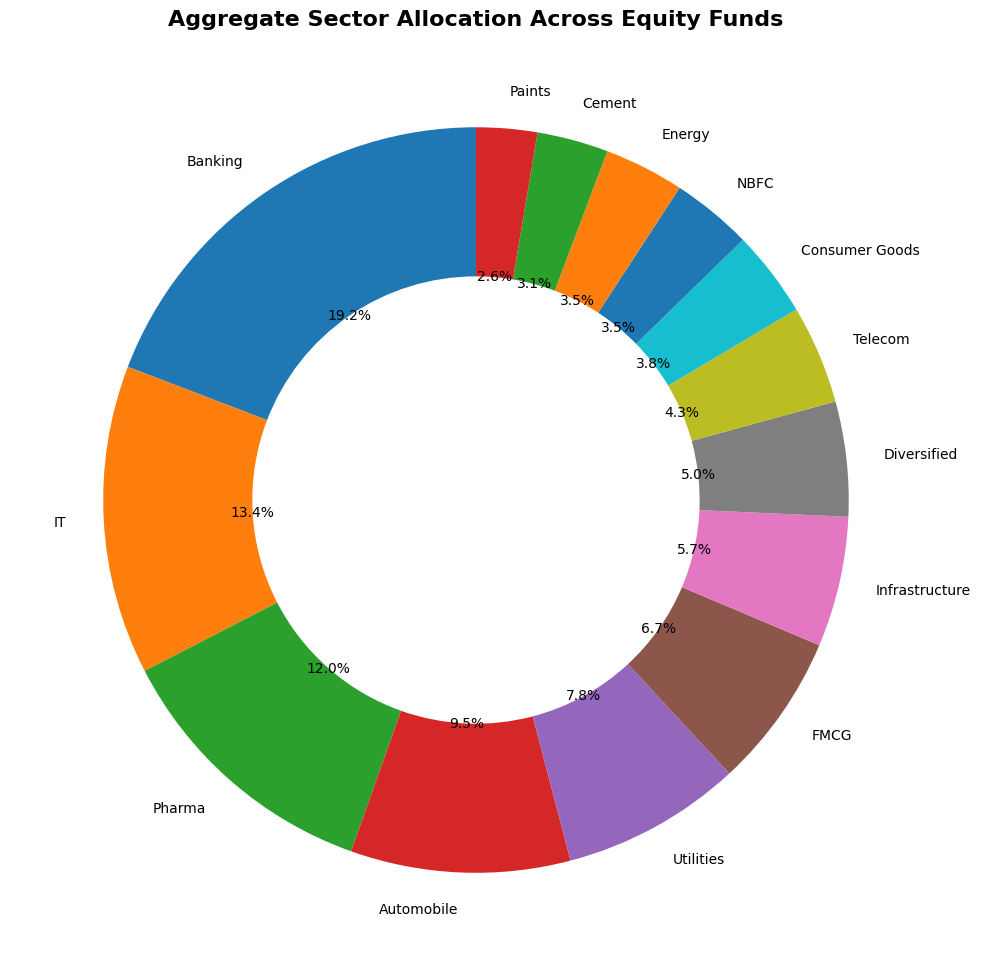

In [43]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

results_dir = Path("Results")
results_dir.mkdir(exist_ok=True)


def _safe_filename(text, fallback):
    text = re.sub(r"[^\w\s-]", "", text).strip().lower()
    text = re.sub(r"[-\s]+", "_", text)
    return text or fallback


def save_current_figure(name):
    base = _safe_filename(name, "figure")
    file_path = results_dir / f"{base}.png"
    suffix = 2
    while file_path.exists():
        file_path = results_dir / f"{base}_{suffix}.png"
        suffix += 1
    plt.gcf().savefig(file_path, bbox_inches="tight", dpi=300)
    print(f"Saved {file_path.name}")


plt.figure(figsize=(10,10))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title(
    "Aggregate Sector Allocation Across Equity Funds",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
save_current_figure("Aggregate Sector Allocation Across Equity Funds")
plt.show()


In [44]:
from pathlib import Path

results_dir = Path("Results")
saved_files = sorted(p.name for p in results_dir.glob("*.png"))
print(f"Found {len(saved_files)} PNG file(s) in: {results_dir.resolve()}")
for file_name in saved_files:
    print(f"- {file_name}")


Found 10 PNG file(s) in: D:\BlueStocks\MFA\Results
- Average Indexed NAV by Fund Category (2022-2025).png
- Average Indexed NAV by Fund House (2022-2025).png
- Top 10 Performing Mutual Fund Schemes.png
- aggregate_sector_allocation_across_equity_funds.png
- aggregate_sector_allocation_across_equity_funds_2.png
- aum_growth_by_fund_house_2022_2025.png
- aum_growth_by_fund_house_2022_2025_2.png
- correlation_matrix_of_daily_fund_returns.png
- correlation_matrix_of_daily_fund_returns_2.png
- newplot.png
